In [36]:
import pandas as pd
import matplotlib.pyplot as plt 

In [37]:
df=pd.read_csv("Iris.csv")

In [38]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [39]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [40]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [64]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [65]:
x = df.drop(columns=["Id","Species"])
y=df["Species"]

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=1)

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler=StandardScaler()
scaler.fit(x_train)
x_train=scaler.transform(x_train)
x_test=scaler.transform(x_test)

In [70]:
lab=["Iris-setosa","Iris-versicolor","Iris-virginica"]

In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
knn=KNeighborsClassifier(n_neighbors=5)
svm=SVC()
lst=[knn,svm]

In [72]:
for i in lst:
    print("model______________",i)
    print(i.fit(x_train,y_train))
    y_pred=i.predict(x_test)

    print("confusion matrix____________",i)
    print(confusion_matrix(y_pred,y_test))

    print("accurancy score__________")
    print(accuracy_score(y_pred,y_test))


model______________ KNeighborsClassifier()
KNeighborsClassifier()
confusion matrix____________ KNeighborsClassifier()
[[13  0  0]
 [ 0 15  0]
 [ 0  1  9]]
accurancy score__________
0.9736842105263158
model______________ SVC()
SVC()
confusion matrix____________ SVC()
[[13  0  0]
 [ 0 15  0]
 [ 0  1  9]]
accurancy score__________
0.9736842105263158


In [73]:
cm=confusion_matrix(y_pred,y_test)

In [74]:
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)

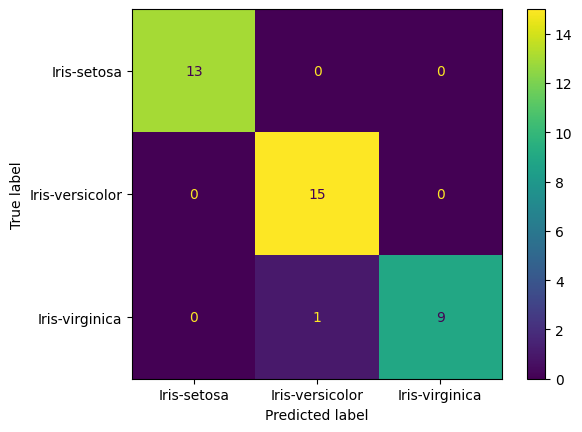

In [75]:
cmd.plot()